In [1]:
!pip install yfinance pandas numpy matplotlib seaborn -q



In [10]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f8f9fa'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.alpha']       = 0.3
print("✅ Cell 1 done — libraries loaded")

✅ Cell 1 done — libraries loaded


In [20]:
TICKER = "^NSEBANK"
STRATEGY_NAME = "Nifty Bank EMA Cross"

# ── Date range ──
START = "2019-01-01"
END   = "2024-12-31"

# ── Capital & position sizing ──
CAPITAL  = 1_000_000   # Starting capital in ₹
LOT      = 75          # Nifty=75, BankNifty=15
SLIP     = 0           # Slippage in points per side
BROK     = 0          # Brokerage per side in ₹

# ── Strategy selector ──
# Options: "RSI", "MACD", "EMA_CROSS", "SUPERTREND"
STRATEGY = "EMA_CROSS"

# ── RSI Parameters (used when STRATEGY = "RSI") ──
RSI_LEN        = 10    # RSI period
RSI_OVERSOLD   = 45    # Buy when RSI crosses above this
RSI_OVERBOUGHT = 65    # Sell when RSI crosses above this
RSI_EMA_FILTER = 0   # Trend filter — set 0 to disable

# ── MACD Parameters (used when STRATEGY = "MACD") ──
MACD_FAST   = 12
MACD_SLOW   = 26
MACD_SIGNAL = 9
MACD_EMA_FILTER = 50   # Trend filter — set 0 to disable

# ── EMA Cross Parameters (used when STRATEGY = "EMA_CROSS") ──
EMA_FAST = 9
EMA_SLOW = 21

# ── Supertrend Parameters (used when STRATEGY = "SUPERTREND") ──
ST_ATR_LEN = 7
ST_FACTOR  = 2
print("✅ Cell 2 done — parameters set")
print(f"   Ticker   : {TICKER}")
print(f"   Strategy : {STRATEGY}")
print(f"   Period   : {START} to {END}")
print(f"   Capital  : ₹{CAPITAL:,.0f}  |  Lot: {LOT}  |  Slip: {SLIP}pts")



✅ Cell 2 done — parameters set
   Ticker   : ^NSEBANK
   Strategy : EMA_CROSS
   Period   : 2019-01-01 to 2024-12-31
   Capital  : ₹1,000,000  |  Lot: 75  |  Slip: 0pts


In [21]:
raw = yf.download(TICKER, start=START, end=END,
                  auto_adjust=True, progress=False)

raw = raw.copy()
raw.columns = [c[0] if isinstance(c, tuple) else c for c in raw.columns]
df = raw[['Open','High','Low','Close','Volume']].copy()
for col in df.columns:
    df[col] = df[col].astype(float)
df.dropna(inplace=True)
df.index = pd.to_datetime(df.index)

print(f"✅ Cell 3 done — {len(df)} days downloaded")
print(f"   {df.index[0].date()} → {df.index[-1].date()}")
print(f"   Price: ₹{df['Close'].iloc[0]:,.0f} → ₹{df['Close'].iloc[-1]:,.0f} "
      f"({(df['Close'].iloc[-1]/df['Close'].iloc[0]-1)*100:.1f}%)")



✅ Cell 3 done — 1478 days downloaded
   2019-01-01 → 2024-12-30
   Price: ₹27,392 → ₹50,953 (86.0%)


In [22]:
df['LongEntry'] = False
df['LongExit']  = False
WARMUP = 30   # bars to skip before trading

if STRATEGY == "RSI":
    delta    = df['Close'].diff()
    gain     = delta.clip(lower=0)
    loss     = (-delta).clip(lower=0)
    avg_gain = gain.ewm(com=RSI_LEN - 1, adjust=False).mean()
    avg_loss = loss.ewm(com=RSI_LEN - 1, adjust=False).mean()
    rs       = avg_gain / avg_loss
    df['IND1'] = 100 - (100 / (1 + rs))          # RSI
    df['IND1_prev'] = df['IND1'].shift(1)

    if RSI_EMA_FILTER > 0:
        df['TREND'] = df['Close'].ewm(
            span=RSI_EMA_FILTER, adjust=False).mean()
        trend_ok = df['Close'] > df['TREND']
        WARMUP   = RSI_EMA_FILTER
    else:
        trend_ok = pd.Series(True, index=df.index)

    df['LongEntry'] = (
        (df['IND1_prev'] < RSI_OVERSOLD) &
        (df['IND1'] >= RSI_OVERSOLD) &
        trend_ok
    )
    df['LongExit'] = (
        (df['IND1_prev'] < RSI_OVERBOUGHT) &
        (df['IND1'] >= RSI_OVERBOUGHT)
    )
    print(f"   RSI({RSI_LEN}) | Oversold:{RSI_OVERSOLD} "
          f"Overbought:{RSI_OVERBOUGHT} | EMA filter:{RSI_EMA_FILTER}")

elif STRATEGY == "MACD":
    df['EMA_F']  = df['Close'].ewm(span=MACD_FAST,   adjust=False).mean()
    df['EMA_S']  = df['Close'].ewm(span=MACD_SLOW,   adjust=False).mean()
    df['IND1']   = df['EMA_F'] - df['EMA_S']         # MACD line
    df['IND2']   = df['IND1'].ewm(
        span=MACD_SIGNAL, adjust=False).mean()       # Signal line
    df['IND1_prev'] = df['IND1'].shift(1)
    df['IND2_prev'] = df['IND2'].shift(1)

    if MACD_EMA_FILTER > 0:
        df['TREND'] = df['Close'].ewm(
            span=MACD_EMA_FILTER, adjust=False).mean()
        trend_ok = df['Close'] > df['TREND']
        WARMUP   = MACD_EMA_FILTER
    else:
        trend_ok = pd.Series(True, index=df.index)

    df['LongEntry'] = (
        (df['IND1_prev'] < df['IND2_prev']) &
        (df['IND1'] >= df['IND2']) &
        trend_ok
    )
    df['LongExit'] = (
        (df['IND1_prev'] > df['IND2_prev']) &
        (df['IND1'] <= df['IND2'])
    )
    print(f"   MACD({MACD_FAST},{MACD_SLOW},{MACD_SIGNAL}) | "
          f"EMA filter:{MACD_EMA_FILTER}")

elif STRATEGY == "EMA_CROSS":
    df['IND1']      = df['Close'].ewm(span=EMA_FAST, adjust=False).mean()
    df['IND2']      = df['Close'].ewm(span=EMA_SLOW, adjust=False).mean()
    df['IND1_prev'] = df['IND1'].shift(1)
    df['IND2_prev'] = df['IND2'].shift(1)
    WARMUP          = EMA_SLOW

    df['LongEntry'] = (
        (df['IND1_prev'] < df['IND2_prev']) &
        (df['IND1'] >= df['IND2'])
    )
    df['LongExit'] = (
        (df['IND1_prev'] > df['IND2_prev']) &
        (df['IND1'] <= df['IND2'])
    )
    print(f"   EMA Cross: Fast {EMA_FAST} / Slow {EMA_SLOW}")

elif STRATEGY == "SUPERTREND":
    hl   = df['High'] - df['Low']
    hc   = (df['High'] - df['Close'].shift(1)).abs()
    lc   = (df['Low']  - df['Close'].shift(1)).abs()
    atr  = pd.concat([hl, hc, lc], axis=1).max(axis=1)\
             .ewm(span=ST_ATR_LEN, adjust=False).mean()
    ub   = (df['High'] + df['Low']) / 2 + ST_FACTOR * atr
    lb   = (df['High'] + df['Low']) / 2 - ST_FACTOR * atr

    st   = pd.Series(0.0, index=df.index)
    for i in range(1, len(df)):
        cl = df['Close'].iloc[i]
        if cl > st.iloc[i-1]:
            st.iloc[i] = max(lb.iloc[i], st.iloc[i-1])
        else:
            st.iloc[i] = min(ub.iloc[i], st.iloc[i-1])

    df['IND1']      = st
    df['IND1_prev'] = df['IND1'].shift(1)
    WARMUP          = ST_ATR_LEN * 2

    df['LongEntry'] = (
        (df['Close'].shift(1) <= df['IND1_prev']) &
        (df['Close'] > df['IND1'])
    )
    df['LongExit'] = (
        (df['Close'].shift(1) >= df['IND1_prev']) &
        (df['Close'] < df['IND1'])
    )
    print(f"   Supertrend ATR:{ST_ATR_LEN} Factor:{ST_FACTOR}")

print(f"✅ Cell 4 done — indicators built")
print(f"   Entry signals : {df['LongEntry'].sum()}")
print(f"   Exit  signals : {df['LongExit'].sum()}")


   EMA Cross: Fast 9 / Slow 21
✅ Cell 4 done — indicators built
   Entry signals : 33
   Exit  signals : 33


In [23]:
STOP_PCT = 0.04
cash      = float(CAPITAL)
position  = 0
entry_px  = 0.0
entry_dt  = None
trades    = []
portfolio = []

for i in range(WARMUP, len(df)):
    dt      = df.index[i]
    cl      = float(df['Close'].iloc[i])
    entry_s = bool(df['LongEntry'].iloc[i])
    exit_s  = bool(df['LongExit'].iloc[i])
    mtm     = (cl - entry_px) * LOT if position == 1 else 0

    if entry_s and position == 0:
        entry_px = cl + SLIP
        entry_dt = dt
        position = 1

    elif exit_s and position == 1:
        exit_px  = cl - SLIP
        pnl_pts  = exit_px - entry_px
        pnl_rs   = pnl_pts * LOT - BROK * 2
        cash    += pnl_rs
        position = 0
        mtm      = 0
        trades.append({
            'Entry Date'  : entry_dt,
            'Exit Date'   : dt,
            'Entry Price' : round(entry_px, 1),
            'Exit Price'  : round(exit_px,  1),
            'P&L Points'  : round(pnl_pts,  1),
            'P&L Rupees'  : round(pnl_rs,   0),
            'Win'         : pnl_rs > 0,
            'Duration'    : (dt - entry_dt).days,
        })

    portfolio.append({'Date': dt, 'Portfolio': cash + mtm, 'Close': cl})

tdf = pd.DataFrame(trades)
pdf = pd.DataFrame(portfolio).set_index('Date')

print(f"✅ Cell 5 done — backtest complete")
print(f"   Trades : {len(tdf)}")
print(f"   Final  : ₹{cash:,.0f}  |  P&L: ₹{cash - CAPITAL:,.0f}")




✅ Cell 5 done — backtest complete
   Trades : 32
   Final  : ₹2,305,879  |  P&L: ₹1,305,879


In [24]:
if len(tdf) == 0:
    print("❌ No trades generated!")
    print("   Try: lower RSI_OVERSOLD, remove EMA filter, or change STRATEGY")
else:
    tot  = len(tdf)
    wins = int(tdf['Win'].sum())
    loss = tot - wins
    wr   = wins / tot * 100
    lr   = 100 - wr

    pdf['Ret'] = pdf['Portfolio'].pct_change().fillna(0)
    wd = int((pdf['Ret'] > 0).sum())
    ld = int((pdf['Ret'] < 0).sum())

    mr     = pdf['Portfolio'].resample('ME').last().pct_change().dropna() * 100
    yr     = pdf['Portfolio'].resample('YE').last().pct_change().dropna() * 100
    avg_mr = mr.mean()
    avg_yr = yr.mean()

    roll_max = pdf['Portfolio'].cummax()
    dd       = (pdf['Portfolio'] - roll_max) / roll_max * 100
    max_dd   = dd.min()

    final_v  = float(pdf['Portfolio'].iloc[-1])
    tot_ret  = (final_v - CAPITAL) / CAPITAL * 100
    n_yrs    = (pdf.index[-1] - pdf.index[0]).days / 365.25
    ann_ret  = ((final_v / CAPITAL) ** (1 / n_yrs) - 1) * 100

    rf       = 0.065 / 252
    exc      = pdf['Ret'] - rf
    sharpe   = exc.mean() / exc.std() * np.sqrt(252)
    calmar   = ann_ret / abs(max_dd) if max_dd != 0 else 0
    dn       = pdf['Ret'][pdf['Ret'] < rf]
    sortino  = exc.mean() / dn.std() * np.sqrt(252) if len(dn) > 0 else 0

    gw  = tdf[tdf['Win']]['P&L Rupees'].sum()
    gl  = tdf[~tdf['Win']]['P&L Rupees'].sum()
    pf  = abs(gw / gl) if gl != 0 else 99
    aw  = tdf[tdf['Win']]['P&L Rupees'].mean()
    al  = tdf[~tdf['Win']]['P&L Rupees'].mean()
    rr  = abs(aw / al) if al != 0 else 0
    rec = (final_v - CAPITAL) / abs(max_dd / 100 * CAPITAL) \
          if max_dd != 0 else 0

    ws = ls = cw = cl2 = 0
    for w in tdf['Win']:
        if w:  cw+=1; cl2=0; ws=max(ws,cw)
        else:  cl2+=1; cw=0; ls=max(ls,cl2)

    print("=" * 55)
    print(f"   {STRATEGY_NAME.upper()}")
    print(f"   {TICKER} | {START[:4]}–{END[:4]}")
    print("=" * 55)

    print(f"\n📅 BACKTEST PERIOD")
    print(f"   Start              : {pdf.index[0].date()}")
    print(f"   End                : {pdf.index[-1].date()}")
    print(f"   Total Trading Days : {len(pdf):,}")

    print(f"\n💰 RETURNS")
    print(f"   Initial Capital    : ₹{CAPITAL:>12,.0f}")
    print(f"   Final Value        : ₹{final_v:>12,.0f}")
    print(f"   Total Net P&L      : ₹{final_v - CAPITAL:>12,.0f}")
    print(f"   Total Return       : {tot_ret:>8.2f}%")
    print(f"   Annualised Return  : {ann_ret:>8.2f}%")
    print(f"   Avg Monthly Return : {avg_mr:>8.2f}%")
    print(f"   Avg Yearly Return  : {avg_yr:>8.2f}%")

    print(f"\n📊 REQUIRED METRICS")
    print(f"   Winning Days       : {wd:>6,}")
    print(f"   Losing Days        : {ld:>6,}")
    print(f"   Win Rate           : {wr:>7.2f}%")
    print(f"   Loss Rate          : {lr:>7.2f}%")
    print(f"   Max Drawdown       : {max_dd:>7.2f}%")
    print(f"   Calmar Ratio       : {calmar:>7.2f}")
    print(f"   Sharpe Ratio       : {sharpe:>7.2f}")

    print(f"\n⭐ BONUS METRICS")
    print(f"   Sortino Ratio      : {sortino:>7.2f}")
    print(f"   Profit Factor      : {pf:>7.2f}")
    print(f"   Recovery Factor    : {rec:>7.2f}")
    print(f"   Avg Win / Trade    : ₹{aw:>10,.0f}")
    print(f"   Avg Loss / Trade   : ₹{al:>10,.0f}")
    print(f"   Risk/Reward Ratio  : {rr:>7.2f}")
    print(f"   Max Win Streak     : {ws:>3} trades")
    print(f"   Max Loss Streak    : {ls:>3} trades")

    print(f"\n🔄 TRADE SUMMARY")
    print(f"   Total Trades       : {tot:>6}")
    print(f"   Winning Trades     : {wins:>6}")
    print(f"   Losing Trades      : {loss:>6}")
    print(f"   Avg Duration       : {tdf['Duration'].mean():.0f} days")
    print("=" * 55)

    # Year by year
    print(f"\n📅 YEAR-BY-YEAR")
    print("─" * 46)
    ys = float(CAPITAL)
    for yr2 in range(int(START[:4]), int(END[:4]) + 1):
        yd = pdf[pdf.index.year == yr2]
        if len(yd) == 0: continue
        ye   = float(yd['Portfolio'].iloc[-1])
        yret = (ye - ys) / ys * 100
        bar  = "█" * int(abs(yret) / 2)
        tag  = "✅" if yret > 0 else "❌"
        print(f"  {yr2}  {yret:>+7.1f}%  {bar} {tag}")
        ys = ye
    print("─" * 46)


   NIFTY BANK EMA CROSS
   ^NSEBANK | 2019–2024

📅 BACKTEST PERIOD
   Start              : 2019-01-30
   End                : 2024-12-30
   Total Trading Days : 1,457

💰 RETURNS
   Initial Capital    : ₹   1,000,000
   Final Value        : ₹   2,305,879
   Total Net P&L      : ₹   1,305,879
   Total Return       :   130.59%
   Annualised Return  :    15.17%
   Avg Monthly Return :     1.42%
   Avg Yearly Return  :    16.47%

📊 REQUIRED METRICS
   Winning Days       :    462
   Losing Days        :    405
   Win Rate           :   46.88%
   Loss Rate          :   53.12%
   Max Drawdown       :  -28.05%
   Calmar Ratio       :    0.54
   Sharpe Ratio       :    0.46

⭐ BONUS METRICS
   Sortino Ratio      :    0.62
   Profit Factor      :    2.42
   Recovery Factor    :    4.66
   Avg Win / Trade    : ₹   148,299
   Avg Loss / Trade   : ₹   -54,035
   Risk/Reward Ratio  :    2.74
   Max Win Streak     :   2 trades
   Max Loss Streak    :   3 trades

🔄 TRADE SUMMARY
   Total Trades       :

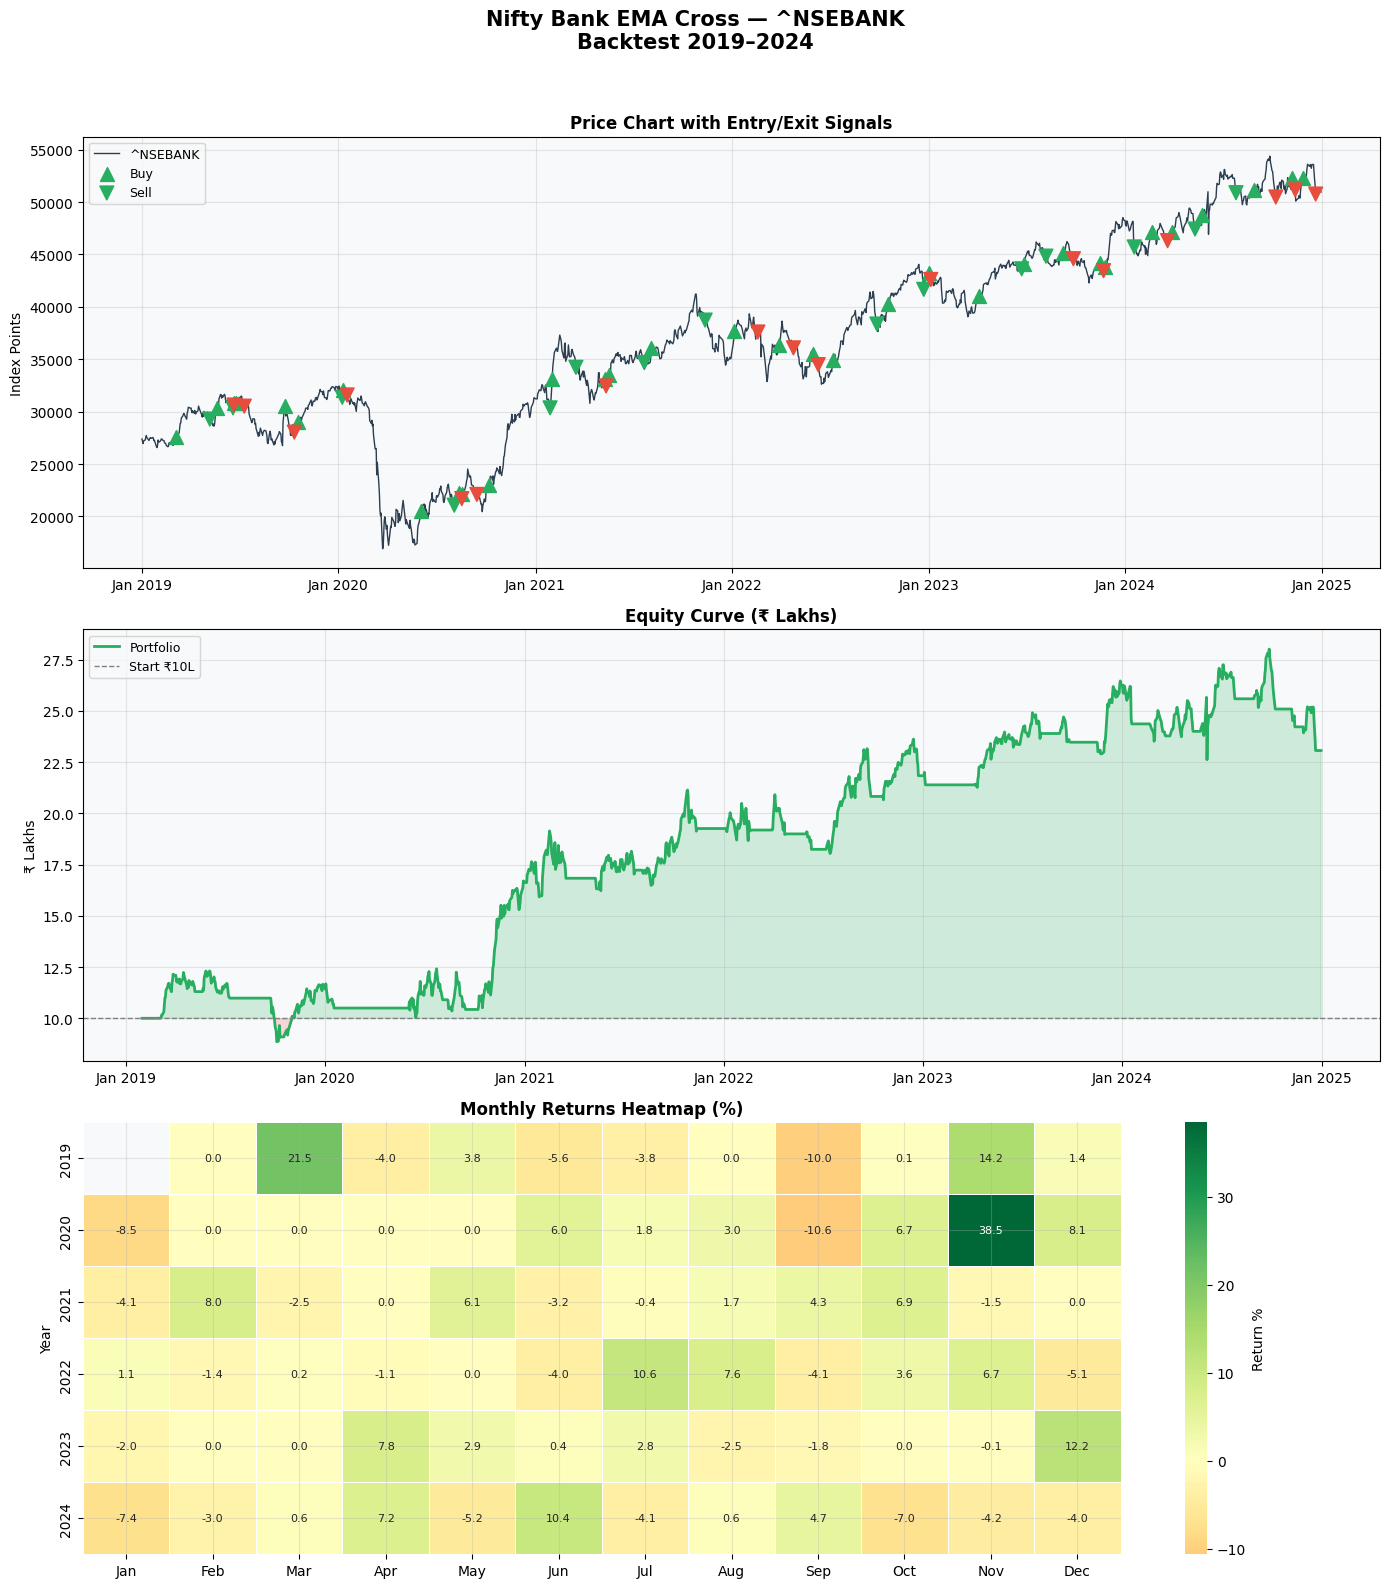

✅ Chart saved → backtest_NSEBANK_EMA_CROSS.png


In [25]:
fig, axes = plt.subplots(3, 1, figsize=(14, 16))
fig.suptitle(f'{STRATEGY_NAME} — {TICKER}\nBacktest {START[:4]}–{END[:4]}',
             fontsize=15, fontweight='bold', y=0.99)

# Chart 1: Price + trade markers
ax1 = axes[0]
ax1.plot(df.index, df['Close'], color='#2c3e50', lw=1.0, label=TICKER)
if 'TREND' in df.columns:
    ax1.plot(df.index, df['TREND'], color='#8e44ad', lw=1.5,
             ls='--', label=f'Trend Filter EMA')
if not tdf.empty:
    ax1.scatter(tdf['Entry Date'], tdf['Entry Price'],
                marker='^', color='#27ae60', s=100, zorder=5, label='Buy')
    ax1.scatter(tdf['Exit Date'], tdf['Exit Price'],
                marker='v', s=100, zorder=5, label='Sell',
                color=['#27ae60' if w else '#e74c3c' for w in tdf['Win']])
ax1.set_title('Price Chart with Entry/Exit Signals', fontweight='bold')
ax1.set_ylabel('Index Points')
ax1.legend(loc='upper left', fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Chart 2: Equity Curve + Drawdown
ax2 = axes[1]
pv = pdf['Portfolio'] / 1e5
ic = CAPITAL / 1e5
ax2.plot(pdf.index, pv, color='#27ae60', lw=2, label='Portfolio')
ax2.axhline(ic, color='gray', lw=1, ls='--', label=f'Start ₹{ic:.0f}L')
ax2.fill_between(pdf.index, ic, pv,
                 where=pv >= ic, alpha=0.2, color='#27ae60')
ax2.fill_between(pdf.index, ic, pv,
                 where=pv < ic, alpha=0.2, color='#e74c3c')
ax2.set_title('Equity Curve (₹ Lakhs)', fontweight='bold')
ax2.set_ylabel('₹ Lakhs')
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Chart 3: Monthly Heatmap
ax3 = axes[2]
mr2   = pdf['Portfolio'].resample('ME').last().pct_change().dropna() * 100
mr_df = pd.DataFrame({
    'Year' : mr2.index.year,
    'Month': mr2.index.month,
    'Ret'  : mr2.values
})
pivot = mr_df.pivot(index='Year', columns='Month', values='Ret')
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec']
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
            ax=ax3, linewidths=0.5, annot_kws={'size': 8},
            cbar_kws={'label': 'Return %'})
ax3.set_title('Monthly Returns Heatmap (%)', fontweight='bold')
ax3.set_ylabel('Year')

plt.tight_layout(rect=[0, 0, 1, 0.97])
fname = f"backtest_{TICKER.replace('^','')}_{STRATEGY}.png"
plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✅ Chart saved → {fname}")

In [26]:
print(f"\n📋 TRADE LOG — {len(tdf)} trades")
print("─" * 72)
if not tdf.empty:
    show = tdf.copy()
    show['Entry Date'] = pd.to_datetime(
        show['Entry Date']).dt.strftime('%d %b %Y')
    show['Exit Date']  = pd.to_datetime(
        show['Exit Date']).dt.strftime('%d %b %Y')
    show['P&L Rupees'] = show['P&L Rupees'].apply(lambda x: f"₹{x:,.0f}")
    show['Win']        = show['Win'].apply(
        lambda x: "WIN ✅" if x else "LOSS ❌")
    show['Duration']   = show['Duration'].apply(lambda x: f"{x}d")
    print(show[['Entry Date', 'Exit Date', 'Entry Price',
                'Exit Price', 'P&L Points', 'P&L Rupees',
                'Win', 'Duration']].to_string(index=False))
print("\n✅ ALL DONE — paste full output here for review")


📋 TRADE LOG — 32 trades
────────────────────────────────────────────────────────────────────────
 Entry Date   Exit Date  Entry Price  Exit Price  P&L Points P&L Rupees    Win Duration
05 Mar 2019 07 May 2019      27553.7     29287.9      1734.1   ₹130,060  WIN ✅      63d
21 May 2019 19 Jun 2019      30308.0     30361.7        53.7     ₹4,027  WIN ✅      29d
20 Jun 2019 21 Jun 2019      30780.7     30628.0      -152.7   ₹-11,456 LOSS ❌       1d
25 Jun 2019 10 Jul 2019      30846.7     30521.7      -324.9   ₹-24,371 LOSS ❌      15d
23 Sep 2019 11 Oct 2019      30565.8     28042.2     -2523.7  ₹-189,275 LOSS ❌      18d
17 Oct 2019 08 Jan 2020      28989.1     31373.3      2384.2   ₹178,813  WIN ✅      83d
10 Jan 2020 17 Jan 2020      32097.0     31590.3      -506.7   ₹-38,006 LOSS ❌       7d
02 Jun 2020 03 Aug 2020      20530.0     21071.9       541.9    ₹40,642  WIN ✅      62d
12 Aug 2020 17 Aug 2020      22263.7     21700.6      -563.1   ₹-42,236 LOSS ❌       5d
18 Aug 2020 14 Sep 202


   MARKET REGIME ANALYSIS

Regime                         Period                   Strategy   Trades   Result
────────────────────────────────────────────────────────────────────────────────
Pre-COVID Bull (2019)          2019-01 → 2020-01           +5.0%       7  ✅
COVID Crash (Feb-Mar 2020)     2020-02 → 2020-05           +0.0%       0  ❌
Post-COVID Rally (2020-21)     2020-06 → 2021-12          +83.4%       8  ✅
Rate Hike Bear (2022)          2022-01 → 2022-12          +13.4%       5  ✅
Recovery & Chop (2023)         2023-01 → 2023-12          +20.4%       6  ✅
Bull & Correction (2024)       2024-01 → 2024-12          -12.2%       6  ❌
────────────────────────────────────────────────────────────────────────────────

📊 REGIME SUMMARY
   Profitable regimes : 4/6
   Best regime        : +83.4%
   Worst regime       : -12.2%
   Avg regime return  : +18.3%


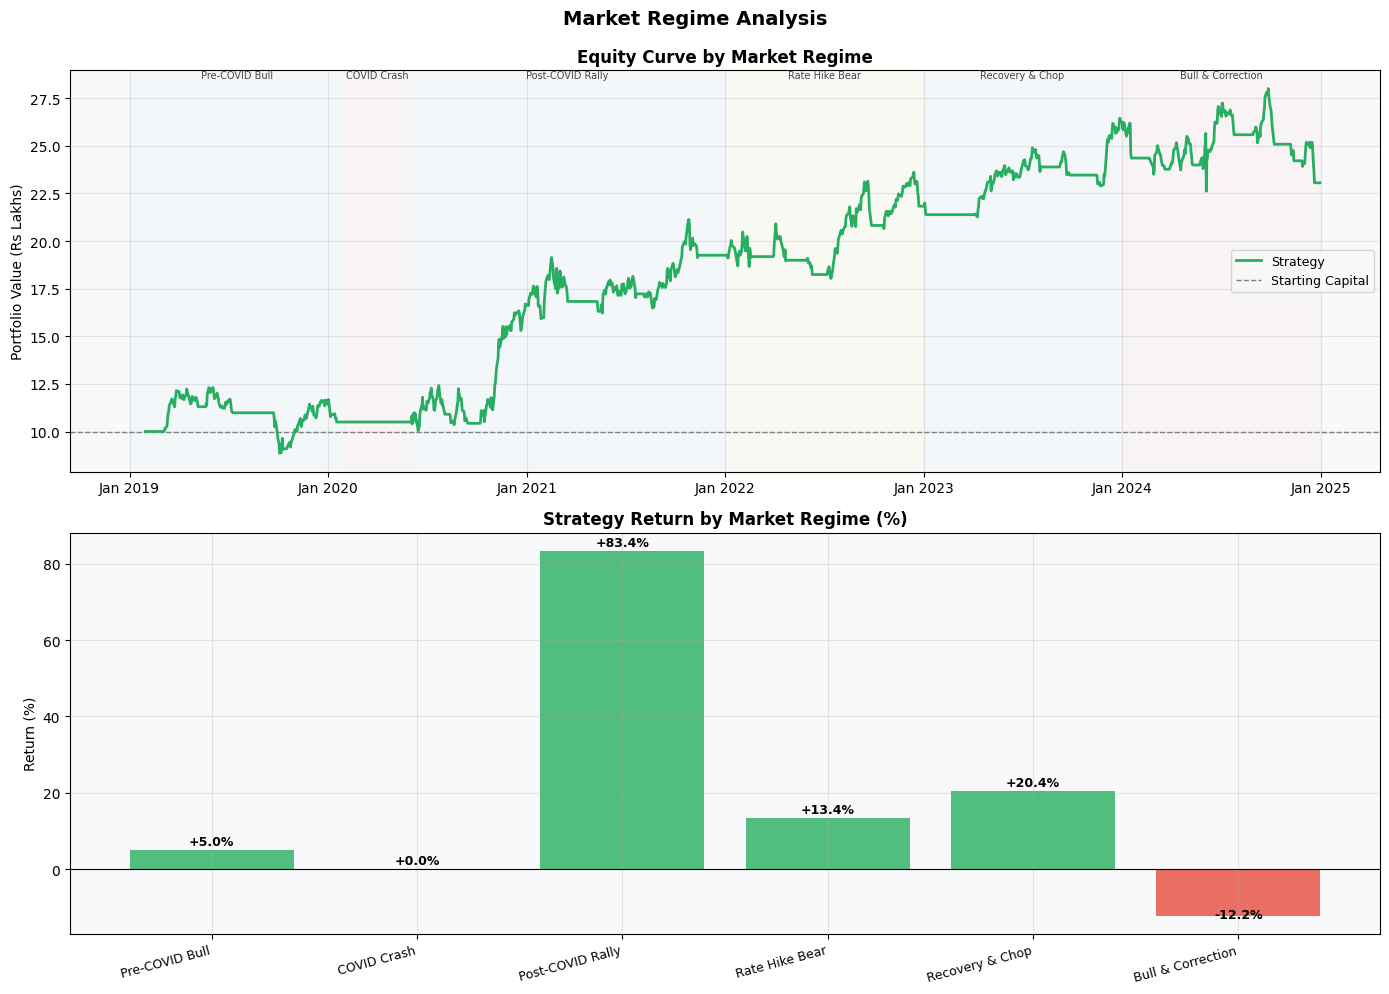


✅ Regime chart saved → regime_analysis.png


In [27]:
print("\n" + "="*55)
print("   MARKET REGIME ANALYSIS")
print("="*55)

# Define regimes — based on actual Bank Nifty / Nifty history
regimes = {
    "Pre-COVID Bull (2019)"      : ("2019-01-01", "2020-01-31"),
    "COVID Crash (Feb-Mar 2020)" : ("2020-02-01", "2020-05-31"),
    "Post-COVID Rally (2020-21)" : ("2020-06-01", "2021-12-31"),
    "Rate Hike Bear (2022)"      : ("2022-01-01", "2022-12-31"),
    "Recovery & Chop (2023)"     : ("2023-01-01", "2023-12-31"),
    "Bull & Correction (2024)"   : ("2024-01-01", "2024-12-31"),
}

print(f"\n{'Regime':<30} {'Period':<22} {'Strategy':>10} {'Trades':>8} {'Result':>8}")
print("─" * 80)

for regime_name, (r_start, r_end) in regimes.items():
    # Filter portfolio for this regime period
    mask = (pdf.index >= r_start) & (pdf.index <= r_end)
    r_pdf = pdf[mask]

    if len(r_pdf) == 0:
        continue

    # Strategy return in this regime
    r_start_val = float(r_pdf['Portfolio'].iloc[0])
    r_end_val   = float(r_pdf['Portfolio'].iloc[-1])
    r_ret       = (r_end_val - r_start_val) / r_start_val * 100

    # Trades in this regime
    if not tdf.empty:
        t_mask  = (pd.to_datetime(tdf['Entry Date']) >= r_start) & \
                  (pd.to_datetime(tdf['Entry Date']) <= r_end)
        r_trades = t_mask.sum()
    else:
        r_trades = 0

    tag = "✅" if r_ret > 0 else "❌"
    period_str = f"{r_start[:7]} → {r_end[:7]}"
    print(f"{regime_name:<30} {period_str:<22} {r_ret:>+9.1f}%"
          f" {r_trades:>7}  {tag}")

print("─" * 80)

# Regime summary stats
print(f"\n📊 REGIME SUMMARY")
regime_returns = []
for regime_name, (r_start, r_end) in regimes.items():
    mask  = (pdf.index >= r_start) & (pdf.index <= r_end)
    r_pdf = pdf[mask]
    if len(r_pdf) == 0: continue
    r_ret = (float(r_pdf['Portfolio'].iloc[-1]) -
             float(r_pdf['Portfolio'].iloc[0])) / \
             float(r_pdf['Portfolio'].iloc[0]) * 100
    regime_returns.append(r_ret)

profitable_regimes = sum(1 for r in regime_returns if r > 0)
print(f"   Profitable regimes : {profitable_regimes}/{len(regime_returns)}")
print(f"   Best regime        : {max(regime_returns):+.1f}%")
print(f"   Worst regime       : {min(regime_returns):+.1f}%")
print(f"   Avg regime return  : {sum(regime_returns)/len(regime_returns):+.1f}%")

# Regime chart
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Market Regime Analysis', fontsize=14,
             fontweight='bold', y=0.99)

# Chart 1: Equity curve with regime backgrounds
ax1 = axes[0]
ax1.plot(pdf.index, pdf['Portfolio'] / 1e5,
         color='#27ae60', lw=2, label='Strategy', zorder=3)

# Shade regimes
regime_colors = ['#EBF5FB', '#FDEDEC', '#EBF5FB',
                 '#FEF9E7', '#EBF5FB', '#F9EBEA']
regime_labels = list(regimes.keys())
for idx, (rn, (rs, re)) in enumerate(regimes.items()):
    ax1.axvspan(pd.Timestamp(rs), pd.Timestamp(re),
                alpha=0.3,
                color=regime_colors[idx % len(regime_colors)],
                zorder=1)
    # Add regime label at top
    mid = pd.Timestamp(rs) + (pd.Timestamp(re) - pd.Timestamp(rs)) / 2
    ax1.text(mid, ax1.get_ylim()[1] if ax1.get_ylim()[1] > 0 else 12,
             rn.split("(")[0].strip(),
             ha='center', va='top', fontsize=7,
             color='#444444', rotation=0)

ax1.axhline(CAPITAL / 1e5, color='gray', lw=1, ls='--',
            label='Starting Capital')
ax1.set_title('Equity Curve by Market Regime', fontweight='bold')
ax1.set_ylabel('Portfolio Value (Rs Lakhs)')
ax1.legend(fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

# Chart 2: Bar chart of regime returns
ax2 = axes[1]
r_names  = []
r_values = []
for rn, (rs, re) in regimes.items():
    mask  = (pdf.index >= rs) & (pdf.index <= re)
    r_pdf = pdf[mask]
    if len(r_pdf) == 0: continue
    r_ret = (float(r_pdf['Portfolio'].iloc[-1]) -
             float(r_pdf['Portfolio'].iloc[0])) / \
             float(r_pdf['Portfolio'].iloc[0]) * 100
    r_names.append(rn.split("(")[0].strip())
    r_values.append(r_ret)

colors = ['#27ae60' if v > 0 else '#e74c3c' for v in r_values]
bars = ax2.bar(range(len(r_names)), r_values, color=colors, alpha=0.8)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_xticks(range(len(r_names)))
ax2.set_xticklabels(r_names, rotation=15, ha='right', fontsize=9)
ax2.set_title('Strategy Return by Market Regime (%)',
              fontweight='bold')
ax2.set_ylabel('Return (%)')

# Add value labels on bars
for bar, val in zip(bars, r_values):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.5 if val >= 0 else -1.5),
             f'{val:+.1f}%', ha='center', va='bottom',
             fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('regime_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("\n✅ Regime chart saved → regime_analysis.png")



In [28]:
# Quick sensitivity test — paste as new cell in S2 notebook
results = []
for fast, slow in [(9,21),(15,30),(20,50),(25,75),(30,100)]:
    df['EF'] = df['Close'].ewm(span=fast, adjust=False).mean()
    df['ES'] = df['Close'].ewm(span=slow, adjust=False).mean()
    df['E']  = (df['EF'].shift(1) < df['ES'].shift(1)) & (df['EF'] >= df['ES'])
    df['X']  = (df['EF'].shift(1) > df['ES'].shift(1)) & (df['EF'] <= df['ES'])

    c = float(CAPITAL)
    ep = 0.0
    pos = 0
    pvals = []
    for i in range(slow, len(df)):
        cl = float(df['Close'].iloc[i])
        mtm = (cl - ep) * LOT if pos == 1 else 0
        if bool(df['E'].iloc[i]) and pos == 0:
            ep = cl; pos = 1
        elif pos == 1:
            if bool(df['X'].iloc[i]) or cl < ep * 0.97:
                c += (cl - ep) * LOT; pos = 0; ep = 0
        pvals.append(c + mtm)

    pv = pd.Series(pvals)
    ret = (pv.iloc[-1] - CAPITAL) / CAPITAL * 100
    rm  = ((pv - pv.cummax()) / pv.cummax() * 100).min()
    results.append((f"EMA {fast}/{slow}", round(ret,1), round(rm,1)))

print(f"\n{'Parameters':<12} {'Return':>10} {'Max DD':>10}")
print("─" * 35)
for r in results:
    print(f"{r[0]:<12} {r[1]:>9.1f}% {r[2]:>9.1f}%")
print("─" * 35)
print("Consistent results = strategy is robust, not overfitted")


Parameters       Return     Max DD
───────────────────────────────────
EMA 9/21         103.8%     -28.1%
EMA 15/30        136.0%     -37.3%
EMA 20/50         68.5%     -39.0%
EMA 25/75         46.5%     -49.2%
EMA 30/100        66.0%     -43.2%
───────────────────────────────────
Consistent results = strategy is robust, not overfitted
